# Heston Model Pricing Methods: Performance Benchmark

This notebook compares different Heston option pricing methods:
- **Monte Carlo** (reference method)
- **FFT** (Carr-Madan Fast Fourier Transform)
- **Quadrature** (numerical integration)
- **Rectangular** (simple numerical integration)
- **Neural Network Surrogate** (trained surrogate model)

**Metrics:**
- Pricing accuracy (vs Monte Carlo reference)
- Execution time
- Trade-off analysis

In [17]:
import os
import sys
from pathlib import Path
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from scipy import stats

# Add project paths
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from heston_model import HestonModel
from neural_networks import HestonSurrogateNetwork

# Set up plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.figsize': (10, 6)
})

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model copy


## 1. Setup: Model Parameters and Test Options

In [18]:
# Heston model parameters (non-calibrated, fixed for comparison)
HESTON_PARAMS = {
    'v0': 0.04,      # Initial variance
    'kappa': 2.0,   # Mean reversion speed
    'theta': 0.04,  # Long-term variance
    'sigma': 0.3,   # Volatility of volatility
    'rho': -0.7,    # Correlation
    'r': 0.04,      # Risk-free rate
    'q': 0.0,       # Dividend yield
    'lambd': 0.0    # Variance risk premium
}

# Market parameters
S0 = 100.0  # Spot price

# Test options: varying strikes and maturities
test_options = [
    {'K': 90, 'tau': 0.25, 'label': 'ITM, 3M'},
    {'K': 100, 'tau': 0.25, 'label': 'ATM, 3M'},
    {'K': 110, 'tau': 0.25, 'label': 'OTM, 3M'},
    {'K': 90, 'tau': 0.50, 'label': 'ITM, 6M'},
    {'K': 100, 'tau': 0.50, 'label': 'ATM, 6M'},
    {'K': 110, 'tau': 0.50, 'label': 'OTM, 6M'},
    {'K': 90, 'tau': 1.00, 'label': 'ITM, 1Y'},
    {'K': 100, 'tau': 1.00, 'label': 'ATM, 1Y'},
    {'K': 110, 'tau': 1.00, 'label': 'OTM, 1Y'},
]

print(f"Test options: {len(test_options)} options")
print(f"Heston parameters: v0={HESTON_PARAMS['v0']:.3f}, kappa={HESTON_PARAMS['kappa']:.1f}, ")
print(f"  theta={HESTON_PARAMS['theta']:.3f}, sigma={HESTON_PARAMS['sigma']:.2f}, rho={HESTON_PARAMS['rho']:.2f}")

Test options: 9 options
Heston parameters: v0=0.040, kappa=2.0, 
  theta=0.040, sigma=0.30, rho=-0.70


## 2. Load Pricing Methods

In [19]:
# Create Heston model instance
heston_model = HestonModel(
    kappa=HESTON_PARAMS['kappa'],
    theta=HESTON_PARAMS['theta'],
    sigma=HESTON_PARAMS['sigma'],
    rho=HESTON_PARAMS['rho'],
    v0=HESTON_PARAMS['v0'],
    r=HESTON_PARAMS['r'],
    q=HESTON_PARAMS['q'],
    lambd=HESTON_PARAMS['lambd']
)

print(" Heston model created")

# Load Neural Network Surrogate (if available)
nn_model = None
nn_norm_params = None

try:
    # Try to load QQQ model as example (or use a generic trained model)
    model_path = PROJECT_ROOT / 'data' / 'models' / 'QQQ_surrogate.pth'
    if model_path.exists():
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        
        nn_model = HestonSurrogateNetwork(
            hidden_layers=checkpoint['hidden_layers'],
            batch_norm=True,
            dropout=0.1
        )
        nn_model.load_state_dict(checkpoint['model_state_dict'])
        nn_model.eval()
        
        # Set normalization
        X_mean = checkpoint['X_mean']
        X_std = checkpoint['X_std']
        if not isinstance(X_mean, torch.Tensor):
            X_mean = torch.tensor(X_mean, dtype=torch.float32)
        if not isinstance(X_std, torch.Tensor):
            X_std = torch.tensor(X_std, dtype=torch.float32)
        nn_model.set_normalization(X_mean, X_std)
        
        print(" Neural Network Surrogate loaded")
    else:
        print(" NN model not found, will skip NN pricing")
except Exception as e:
    print(f" Could not load NN model: {e}")
    nn_model = None

 Heston model created
 Neural Network Surrogate loaded


## 3. Monte Carlo Reference Prices

In [20]:
# Compute Monte Carlo reference prices (high accuracy)
MC_N_PATHS = 100000  # High number for accurate reference
MC_N_STEPS = 252  # Daily steps

print(f"Computing Monte Carlo reference prices ({MC_N_PATHS:,} paths)...")

mc_results = []
mc_start = time.time()

for opt in test_options:
    K = opt['K']
    tau = opt['tau']
    
    result = heston_model.price_option_monte_carlo(
        S0=S0,
        K=K,
        T=tau,
        option_type='call',
        n_paths=MC_N_PATHS,
        n_steps=MC_N_STEPS,
        seed=42
    )
    
    mc_results.append({
        'K': K,
        'tau': tau,
        'label': opt['label'],
        'price': result['price'],
        'std_error': result['std_error'],
        'ci_lower': result['confidence_interval'][0],
        'ci_upper': result['confidence_interval'][1]
    })

mc_time = time.time() - mc_start
mc_df = pd.DataFrame(mc_results)

print(f" Monte Carlo completed in {mc_time:.2f} seconds")
print(f"\nReference prices:")
print(mc_df[['label', 'K', 'tau', 'price', 'std_error']].to_string(index=False))

Computing Monte Carlo reference prices (100,000 paths)...
 Monte Carlo completed in 14.35 seconds

Reference prices:
  label   K  tau     price  std_error
ITM, 3M  90 0.25 11.725117   0.026522
ATM, 3M 100 0.25  4.471362   0.017986
OTM, 3M 110 0.25  0.824663   0.007477
ITM, 6M  90 0.50 13.505110   0.034702
ATM, 6M 100 0.50  6.585207   0.025712
OTM, 6M 110 0.50  2.245786   0.014986
ITM, 1Y  90 1.00 16.472353   0.046920
ATM, 1Y 100 1.00  9.866715   0.037897
OTM, 1Y 110 1.00  5.042756   0.027453


## 4. Benchmark All Pricing Methods

In [21]:
def benchmark_pricing_method(method_name, pricing_func, test_options, mc_prices):
    """
    Benchmark a pricing method: compute prices, timing, and accuracy.
    
    Returns:
        DataFrame with results
    """
    results = []
    
    # Warm-up run (to avoid cold start effects)
    if len(test_options) > 0:
        try:
            pricing_func(S0, test_options[0]['K'], test_options[0]['tau'])
        except:
            pass
    
    # Benchmark
    start_time = time.time()
    
    for opt in test_options:
        K = opt['K']
        tau = opt['tau']
        mc_price = mc_prices[opt['label']]
        
        try:
            opt_start = time.perf_counter()
            price = pricing_func(S0, K, tau)
            opt_time = time.perf_counter() - opt_start
            
            error = abs(price - mc_price)
            rel_error = (error / mc_price * 100) if mc_price > 0 else 0
            
            results.append({
                'method': method_name,
                'K': K,
                'tau': tau,
                'label': opt['label'],
                'price': price,
                'mc_price': mc_price,
                'error': error,
                'rel_error': rel_error,
                'time': opt_time
            })
        except Exception as e:
            print(f"Error with {method_name} for {opt['label']}: {e}")
            results.append({
                'method': method_name,
                'K': K,
                'tau': tau,
                'label': opt['label'],
                'price': np.nan,
                'mc_price': mc_price,
                'error': np.nan,
                'rel_error': np.nan,
                'time': np.nan
            })
    
    total_time = time.time() - start_time
    
    df = pd.DataFrame(results)
    df['total_time'] = total_time
    
    return df

# Create pricing functions
def price_fft(S, K, tau):
    return heston_model.call_price_fft(S, K, tau)

def price_quad(S, K, tau):
    return heston_model.call_price_quad(S, K, tau)

def price_rectangular(S, K, tau):
    return heston_model.call_price_rectangular(S, K, tau)

def price_nn(S, K, tau):
    if nn_model is None:
        raise ValueError("NN model not loaded")
    return nn_model.predict_price(
        S=S, K=K, tau=tau,
        v0=HESTON_PARAMS['v0'],
        kappa=HESTON_PARAMS['kappa'],
        theta=HESTON_PARAMS['theta'],
        sigma=HESTON_PARAMS['sigma'],
        rho=HESTON_PARAMS['rho'],
        r=HESTON_PARAMS['r']
    )

def price_mc(S, K, tau):
    """Monte Carlo pricing (single option, fewer paths for speed)."""
    result = heston_model.price_option_monte_carlo(
        S0=S, K=K, T=tau, option_type="call",
        n_paths=100000, n_steps=252, seed=42
    )
    return result["price"]

# Create MC price lookup
mc_price_dict = {row['label']: row['price'] for _, row in mc_df.iterrows()}

# Benchmark all methods
print("Benchmarking pricing methods...")
print("=" * 60)

all_results = []

# FFT
print("\n[1/5] FFT method...")
fft_results = benchmark_pricing_method('FFT', price_fft, test_options, mc_price_dict)
all_results.append(fft_results)
print(f"  Time: {fft_results['total_time'].iloc[0]:.4f}s, Mean error: {fft_results['error'].mean():.6f}")

# Quadrature
print("\n[2/5] Quadrature method...")
quad_results = benchmark_pricing_method('Quadrature', price_quad, test_options, mc_price_dict)
all_results.append(quad_results)
print(f"  Time: {quad_results['total_time'].iloc[0]:.4f}s, Mean error: {quad_results['error'].mean():.6f}")

# Rectangular
print("\n[3/5] Rectangular method...")
rect_results = benchmark_pricing_method('Rectangular', price_rectangular, test_options, mc_price_dict)
all_results.append(rect_results)
print(f"  Time: {rect_results['total_time'].iloc[0]:.4f}s, Mean error: {rect_results['error'].mean():.6f}")

# Neural Network
if nn_model is not None:
    print("\n[4/5] Neural Network Surrogate...")
    nn_results = benchmark_pricing_method('NN Surrogate', price_nn, test_options, mc_price_dict)
    all_results.append(nn_results)
    print(f"  Time: {nn_results['total_time'].iloc[0]:.4f}s, Mean error: {nn_results['error'].mean():.6f}")
else:
    print("\n[4/5] Neural Network Surrogate: SKIPPED (model not available)")

# Monte Carlo (10K paths for speed comparison)
print("\n[5/5] Monte Carlo (10K paths)...")
mc_results = benchmark_pricing_method('Monte Carlo', price_mc, test_options, mc_price_dict)
all_results.append(mc_results)
print(f"  Time: {mc_results['total_time'].iloc[0]:.4f}s, Mean error: {mc_results['error'].mean():.6f}")

# Combine all results
results_df = pd.concat(all_results, ignore_index=True)

print("\n" + "=" * 60)
print(" Benchmarking complete!")

Benchmarking pricing methods...

[1/5] FFT method...
  Time: 0.0084s, Mean error: 0.037034

[2/5] Quadrature method...
  Time: 0.0118s, Mean error: 0.566080

[3/5] Rectangular method...
  Time: 0.7822s, Mean error: 0.558990

[4/5] Neural Network Surrogate...
  Time: 0.0016s, Mean error: 0.089184

[5/5] Monte Carlo (10K paths)...
  Time: 11.4841s, Mean error: 0.000000

 Benchmarking complete!


## 5. Results Summary

In [22]:
# Summary statistics by method
summary = results_df.groupby('method').agg({
    'error': ['mean', 'std', 'max'],
    'rel_error': ['mean', 'std', 'max'],
    'time': 'mean',
    'total_time': 'first'
}).round(6)

print("\n" + "=" * 80)
print("PERFORMANCE SUMMARY")
print("=" * 80)
print(summary)

# Detailed comparison table
print("\n" + "=" * 80)
print("DETAILED RESULTS")
print("=" * 80)
comparison = results_df.pivot_table(
    index=['label', 'K', 'tau'],
    columns='method',
    values=['price', 'error', 'rel_error', 'time'],
    aggfunc='first'
)
print(comparison.round(6))


PERFORMANCE SUMMARY
                 error                     rel_error                       \
                  mean       std       max      mean       std        max   
method                                                                      
FFT           0.037034  0.015717  0.061212  0.667551  0.386599   1.400822   
Monte Carlo   0.000000  0.000000  0.000000  0.000000  0.000000   0.000000   
NN Surrogate  0.089184  0.054371  0.168597  2.645959  4.276606  13.698338   
Quadrature    0.566080  0.527893  1.719473  9.202601  8.796534  31.171480   
Rectangular   0.558990  0.521293  1.698757  9.220928  9.050264  31.839098   

                  time total_time  
                  mean      first  
method                             
FFT           0.000928   0.008396  
Monte Carlo   1.276004  11.484132  
NN Surrogate  0.000176   0.001597  
Quadrature    0.001309   0.011795  
Rectangular   0.086904   0.782177  

DETAILED RESULTS
                     error                              

## 6. Visualization: Accuracy vs Speed Trade-off

/var/folders/w1/k7fwgp6d65v95lj5q8pp5tx80000gn/T/ipykernel_20172/4264017618.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(mean_time, mean_error,
/var/folders/w1/k7fwgp6d65v95lj5q8pp5tx80000gn/T/ipykernel_20172/4264017618.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(error_data, labels=methods, patch_artist=True)
/var/folders/w1/k7fwgp6d65v95lj5q8pp5tx80000gn/T/ipykernel_20172/4264017618.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


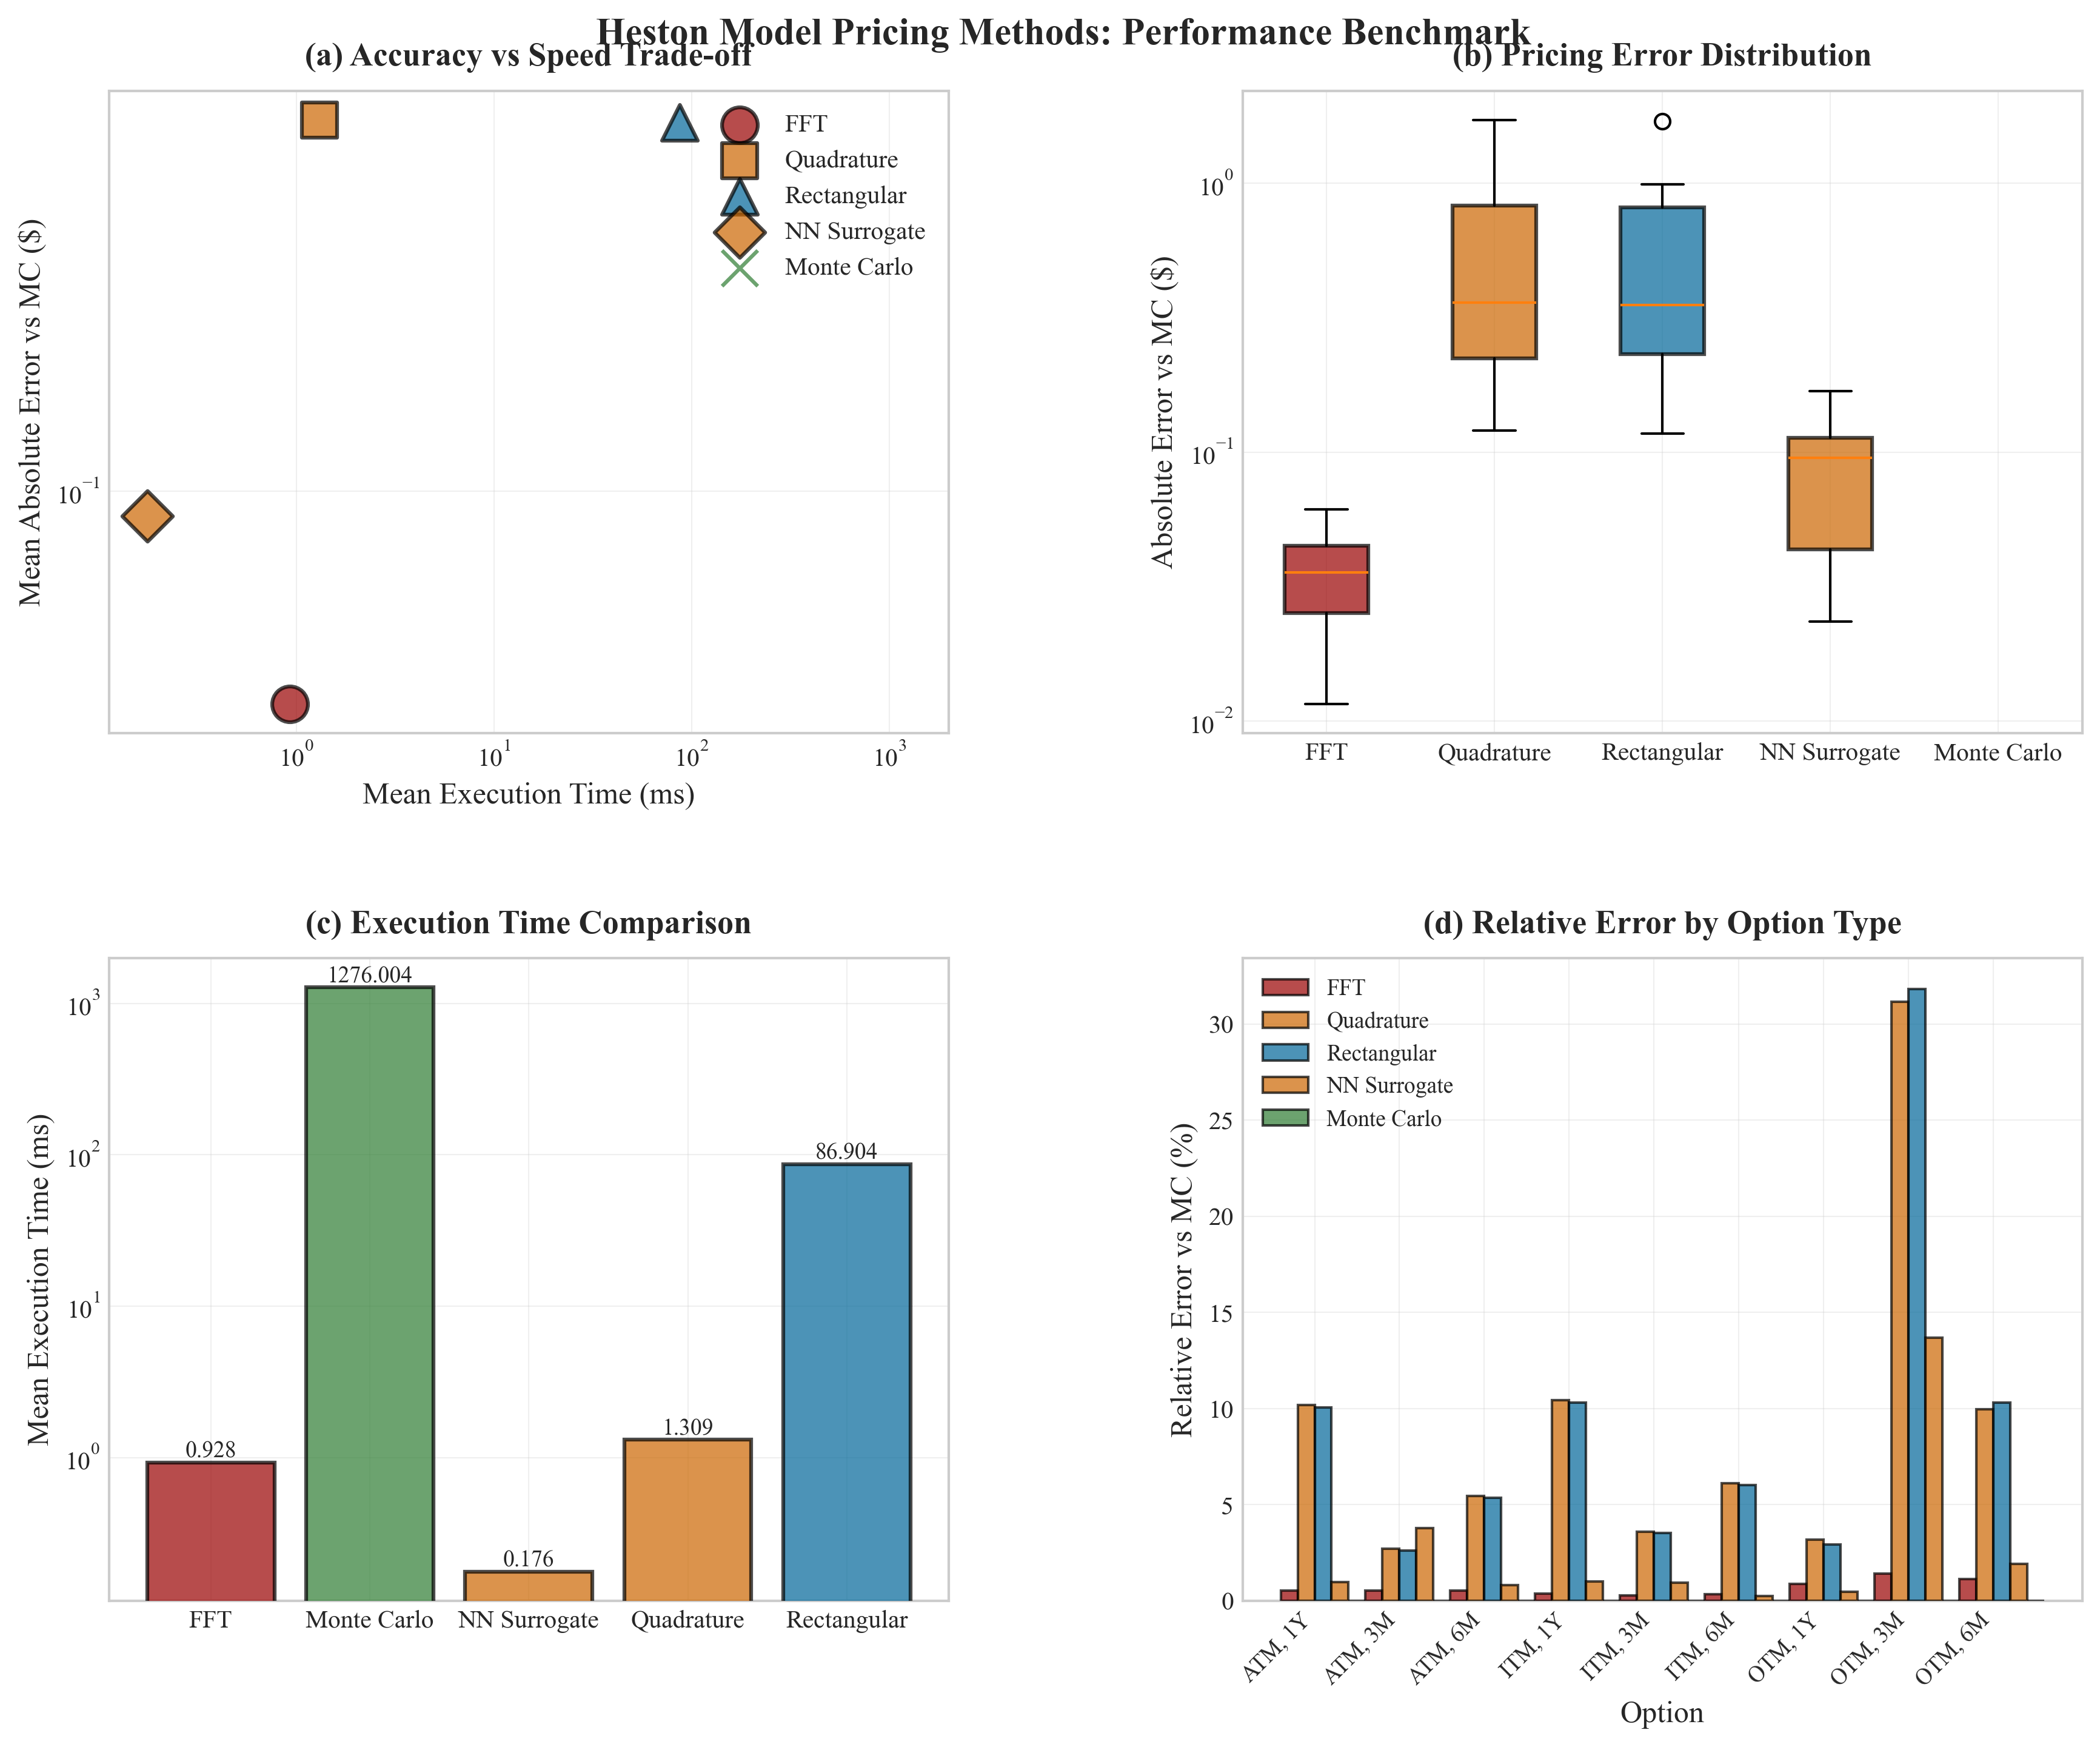


 Saved presentation figures:
   PDF: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model copy/master_dissertation_ppt/figures/pricing_methods_benchmark.pdf
   PNG: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model copy/master_dissertation_ppt/figures/pricing_methods_benchmark.png


In [23]:
# Presentation-style visualization
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set presentation-quality plotting parameters
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

# Create visualization
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.35, top=0.94)

# (a) Accuracy vs Speed scatter
ax1 = fig.add_subplot(gs[0, 0])

methods = results_df['method'].unique()
colors = {'FFT': '#990000', 'Quadrature': '#CC6600', 'Rectangular': '#006699', 'Monte Carlo': '#2E7D32', 'NN Surrogate': '#CC6600'}
markers = {'FFT': 'o', 'Quadrature': 's', 'Rectangular': '^', 'Monte Carlo': 'x', 'NN Surrogate': 'D'}

for method in methods:
    method_data = results_df[results_df['method'] == method]
    mean_time = method_data['time'].mean() * 1000  # Convert to ms
    mean_error = method_data['error'].mean()
    
    ax1.scatter(mean_time, mean_error, 
               s=200, alpha=0.7, 
               color=colors.get(method, '#666666'),
               marker=markers.get(method, 'o'),
               edgecolors='black', linewidth=1.5,
               label=method, zorder=3)

ax1.set_xlabel('Mean Execution Time (ms)', fontsize=12, fontweight='medium')
ax1.set_ylabel('Mean Absolute Error vs MC ($)', fontsize=12, fontweight='medium')
ax1.set_title('(a) Accuracy vs Speed Trade-off', fontsize=13, fontweight='bold', pad=10)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, zorder=0)

# (b) Pricing error by method
ax2 = fig.add_subplot(gs[0, 1])

error_data = [results_df[results_df['method'] == m]['error'].values for m in methods]
bp = ax2.boxplot(error_data, labels=methods, patch_artist=True)

for patch, method in zip(bp['boxes'], methods):
    patch.set_facecolor(colors.get(method, '#CCCCCC'))
    patch.set_alpha(0.7)
    patch.set_linewidth(1.5)

ax2.set_ylabel('Absolute Error vs MC ($)', fontsize=12, fontweight='medium')
ax2.set_title('(b) Pricing Error Distribution', fontsize=13, fontweight='bold', pad=10)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y', zorder=0)

# (c) Execution time comparison
ax3 = fig.add_subplot(gs[1, 0])

time_data = results_df.groupby('method')['time'].mean() * 1000  # ms
bars = ax3.bar(time_data.index, time_data.values, 
               color=[colors.get(m, '#CCCCCC') for m in time_data.index],
               alpha=0.7, edgecolor='black', linewidth=1.5, zorder=3)

ax3.set_ylabel('Mean Execution Time (ms)', fontsize=12, fontweight='medium')
ax3.set_title('(c) Execution Time Comparison', fontsize=13, fontweight='bold', pad=10)
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y', zorder=0)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, zorder=4)

# (d) Relative error by option type
ax4 = fig.add_subplot(gs[1, 1])

rel_error_pivot = results_df.pivot_table(
    index='label',
    columns='method',
    values='rel_error',
    aggfunc='mean'
)

x_pos = np.arange(len(rel_error_pivot.index))
width = 0.2
offset = -1.5 * width

for i, method in enumerate(methods):
    if method in rel_error_pivot.columns:
        ax4.bar(x_pos + offset + i * width, rel_error_pivot[method].values,
               width, label=method, 
               color=colors.get(method, '#CCCCCC'),
               alpha=0.7, edgecolor='black', linewidth=1, zorder=3)

ax4.set_xlabel('Option', fontsize=12, fontweight='medium')
ax4.set_ylabel('Relative Error vs MC (%)', fontsize=12, fontweight='medium')
ax4.set_title('(d) Relative Error by Option Type', fontsize=13, fontweight='bold', pad=10)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(rel_error_pivot.index, rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=9, framealpha=0.9)
ax4.grid(True, alpha=0.3, axis='y', zorder=0)

fig.suptitle('Heston Model Pricing Methods: Performance Benchmark', 
            fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Save figure to presentation figures directory
figures_dir = PROJECT_ROOT / 'master_dissertation_ppt' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

output_path_pdf = figures_dir / 'pricing_methods_benchmark.pdf'
output_path_png = figures_dir / 'pricing_methods_benchmark.png'

fig.savefig(output_path_pdf, bbox_inches='tight', dpi=300)
fig.savefig(output_path_png, bbox_inches='tight', dpi=300)
print(f"\n Saved presentation figures:")
print(f"   PDF: {output_path_pdf}")
print(f"   PNG: {output_path_png}")

## 7. Detailed Comparison Table

In [24]:
# Create detailed comparison table
comparison_table = results_df.pivot_table(
    index='label',
    columns='method',
    values=['price', 'error', 'rel_error', 'time'],
    aggfunc='first'
)

print("\n" + "=" * 100)
print("DETAILED COMPARISON: Price, Error, and Timing")
print("=" * 100)
print(comparison_table.round(6))

# Export to CSV
csv_path = PROJECT_ROOT / 'results' / 'statistics' / 'pricing_methods_benchmark.csv'
results_df.to_csv(csv_path, index=False)
print(f"\n Results exported to: {csv_path}")


DETAILED COMPARISON: Price, Error, and Timing
            error                                                      price  \
method        FFT Monte Carlo NN Surrogate Quadrature Rectangular        FFT   
label                                                                          
ATM, 1Y  0.053671         0.0     0.095460   1.005456    0.991524   9.813044   
ATM, 3M  0.023557         0.0     0.168597   0.120556    0.117312   4.447806   
ATM, 6M  0.035630         0.0     0.053384   0.359945    0.353313   6.549577   
ITM, 1Y  0.061212         0.0     0.163120   1.719473    1.698757  16.411141   
ITM, 3M  0.032759         0.0     0.109360   0.421843    0.414409  11.692358   
ITM, 6M  0.044800         0.0     0.032834   0.825712    0.814040  13.460310   
OTM, 1Y  0.044951         0.0     0.023487   0.161145    0.147343   4.997805   
OTM, 3M  0.011552         0.0     0.112965   0.257060    0.262565   0.813111   
OTM, 6M  0.025179         0.0     0.043449   0.223533    0.231642   2.220